<a href="https://colab.research.google.com/github/Vini1928/tp_lib/blob/Dev/TVR_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Core libraries.
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
# 1. General settings.
pd.set_option('display.max_columns', 100)

# 2. Warnings.
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TVR_prediction/tvr_data_2020_2025.csv', parse_dates=['researchDate', 'programFirstIssueDate'])
data['researchDate'] = pd.to_datetime(data['researchDate'])

In [ ]:
data.head()

,researchDate,researchDayType,tvCompanyId,tvCompanyName,breaksSpotId,breaksStartTime,breaksFinishTime,breaksDuration,breaksPrimeTimeStatusName,programFirstIssueDate,programAgeRestrictionName,programName,programTypeName,programCategoryName,programStartTime,programFinishTime,programDuration,SalesRtgPer
0,2020-01-01,H,1877,5 канал,3676250151,00:13:56,00:17:21,205,Прайм-тайм,2007-09-03 00:00:00,16+,След,Телесериал,Телесериал,00:05:07,00:59:52,3285,1.367364
1,2020-01-01,H,1877,5 канал,3676250162,00:30:02,00:33:27,205,Прайм-тайм,2007-09-03 00:00:00,16+,След,Телесериал,Телесериал,00:05:07,00:59:52,3285,1.196827
2,2020-01-01,H,1877,5 канал,3676250184,01:12:22,01:15:32,190,Вне прайм-тайм,2007-09-03 00:00:00,16+,След,Телесериал,Телесериал,00:59:52,01:45:30,2738,1.118849
3,2020-01-01,H,1877,5 канал,3676250194,01:25:39,01:28:49,190,Вне прайм-тайм,2007-09-03 00:00:00,16+,След,Телесериал,Телесериал,00:59:52,01:45:30,2738,1.123093
4,2020-01-01,H,1877,5 канал,3676250205,01:55:19,01:58:29,190,Вне прайм-тайм,2003-11-04 00:00:00,16+,Детективы,Телесериал,Телесериал,01:45:30,02:19:54,2064,0.764849


In [ ]:
# Проверим количество пропусков в каждом столбце
print(data.isnull().sum())

researchDate                      0
researchDayType                   0
tvCompanyId                       0
tvCompanyName                     0
breaksSpotId                      0
breaksStartTime                   0
breaksFinishTime                  0
breaksDuration                    0
breaksPrimeTimeStatusName         2
programFirstIssueDate             0
programAgeRestrictionName    204849
programName                       0
programTypeName                   0
programCategoryName               0
programStartTime                  0
programFinishTime                 0
programDuration                   0
SalesRtgPer                       0
dtype: int64


### Признаки

**researchDayType - Тип дня.**  
H - праздник.  
W - рабочий день.  
E - выходной.  

In [ ]:
data['researchDayType'].unique()

array(['H', 'W', 'E'], dtype=object)

**tvCompanyName - ТВ каналы.**  
Всего в данных 14 федеральных каналов.  

In [ ]:
data['tvCompanyName'].unique()

array(['5 канал', 'Звезда', 'Мир', 'НТВ', 'Первый', 'РЕН ТВ', 'Россия 24',
       'СТС', 'ТВ Центр', 'ТВ3', 'ТНТ', 'ТНТ4', 'Че', 'Россия 1'],
      dtype=object)

**breaksPrimeTimeStatusName - Прайм или не прайм.**  

In [ ]:
data['breaksPrimeTimeStatusName'].unique()

array(['Прайм-тайм', 'Вне прайм-тайм', nan], dtype=object)

**programAgeRestrictionName - Возрастное ограничение программы.**  

In [ ]:
data['programAgeRestrictionName'].unique()

array(['16+', '12+', nan, '6+', '0+', '18+', '14+', '3+', '21+', '5+',
       '4+'], dtype=object)

**programName - Название программы.**  

In [ ]:
data['programName'].nunique()

15728

**programTypeName - Жанр программы.**  

In [ ]:
print(data['programTypeName'].unique())
print(data['programTypeName'].nunique())

['Телесериал' 'Кинофильм' 'Анимация' 'Музыкальная программа'
 'Развлекательная программа' 'Новости' 'Социально-политическая программа'
 'Спортивная программа' 'Документальная программа'
 'Познавательная программа' 'Прочее' 'Детская программа']
12


**programCategoryName - Категория программы.**  

In [ ]:
print(data['programCategoryName'].unique())
print(data['programCategoryName'].nunique())

['Телесериал' 'Кинофильм' 'Мультипликационный фильм'
 'Мультипликационный сериал' 'Современная музыка, эстрадный концерт'
 'Игра-викторина, соревнование' 'Ежедневные новости'
 'Смешанный концерт, шоу, цирк' 'Криминальные хроники'
 'Информационно-аналитическая передача (комментарии)' 'Экономика и бизнес'
 'Другая информационная передача' 'Прогноз погоды' 'Спортивные новости'
 'Документальный фильм' 'Социально-публицистическая передача'
 'Реалити-шоу' 'Юмористическая передача'
 'Передача об искусстве, культуре, истории'
 'Другая музыкально-танцевальная передача' 'Развлекательное ток-шоу'
 'Передача-интервью' 'Другая развлекательная передача'
 'Документальный сериал' 'Другая познавательная передача'
 'Женская передача, кулинарное шоу' 'Утренний эфир'
 'География и страноведение' 'Трансляция спортивного мероприятия'
 'Спортивный журнал и аналитика' 'Другая социально-политическая передача'
 'Музыкально-развлекательная передача' 'Передача о моде и дизайне'
 'Религиозная передача' 'Передача о

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1505233 entries, 0 to 1505232
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   researchDate               1505233 non-null  datetime64[ns]
 1   researchDayType            1505233 non-null  object        
 2   tvCompanyId                1505233 non-null  int64         
 3   tvCompanyName              1505233 non-null  object        
 4   breaksSpotId               1505233 non-null  int64         
 5   breaksStartTime            1505233 non-null  object        
 6   breaksFinishTime           1505233 non-null  object        
 7   breaksDuration             1505233 non-null  int64         
 8   breaksPrimeTimeStatusName  1505231 non-null  object        
 9   programFirstIssueDate      1505233 non-null  object        
 10  programAgeRestrictionName  1300384 non-null  object        
 11  programName                1505233 no

In [ ]:
data.isna().sum()

,0
researchDate,0
researchDayType,0
tvCompanyId,0
tvCompanyName,0
breaksSpotId,0
breaksStartTime,0
breaksFinishTime,0
breaksDuration,0
breaksPrimeTimeStatusName,2
programFirstIssueDate,0


# Обработка пропусков


In [ ]:
# Находим самый частый возрастной рейтинг для каждого programName
age_by_program = data.groupby('programName')['programAgeRestrictionName'].apply(
    lambda x: x.mode()[0] if not x.mode().empty else None
)

# Заполняем пропуски в исходном DataFrame
data['programAgeRestrictionName'] = data.apply(
    lambda row: age_by_program[row['programName']]
    if pd.isna(row['programAgeRestrictionName'])
    else row['programAgeRestrictionName'],
    axis=1
)

# Проверяем оставшиеся пропуски
print(data['programAgeRestrictionName'].isnull().sum())

68188


In [ ]:
# Заполняем по самой частой возрастной группе в programCategoryName
age_by_category = data.groupby('programCategoryName')['programAgeRestrictionName'].apply(
    lambda x: x.mode()[0] if not x.mode().empty else None
)

data['programAgeRestrictionName'] = data.apply(
    lambda row: age_by_category[row['programCategoryName']]
    if pd.isna(row['programAgeRestrictionName'])
    else row['programAgeRestrictionName'],
    axis=1
)

print(data['programAgeRestrictionName'].isnull().sum())  # Должно быть 0
print(data['programAgeRestrictionName'].value_counts())  # Распределение рейтингов

print(data[data['programAgeRestrictionName'].isna()]['programName'].unique())
print(data[data['programAgeRestrictionName'].isna()]['programCategoryName'].unique())
print(data[data['programAgeRestrictionName'].isna()]['programTypeName'].unique())

255
programAgeRestrictionName
16+    1119251
12+     281745
0+       42460
18+      31389
6+       29918
14+        140
5+          44
21+         20
3+           8
4+           3
Name: count, dtype: int64
['Вести. Церковь и мир' 'Рыбий жыр'
 'Рождественское интервью Святейшего Патриарха Кирилла'
 'К 75-летию. Большое интервью Святейшего Патриарха Московского и всея Руси Кирилла'
 'Вести. Слово' 'Схождение благодатного огня' 'Церковь и мир'
 'Новогоднее обращение Президента России Владимира Владимировича Путина']
['Религиозная передача' 'Стиль жизни и досуг' 'Поздравление']
['Социально-политическая программа' 'Прочее']


Для 255 записей (0.02% данных) можно заполнить самым частым рейтингом "16+"
тк это наиболее распространённый рейтинг (1 119 251 случай), поэтому он будет наименее "вредной" заменой.
+ по категориям можно заметить что эти программы как раз относятся к категории 16+

In [ ]:
data['programAgeRestrictionName'] = data['programAgeRestrictionName'].fillna('16+')

# Проверка распределения
print(data['programAgeRestrictionName'].value_counts(normalize=True))

# Проверка оставшихся пропусков
print("Осталось пропусков:", data['programAgeRestrictionName'].isna().sum())

programAgeRestrictionName
16+    0.743743
12+    0.187177
0+     0.028208
18+    0.020853
6+     0.019876
14+    0.000093
5+     0.000029
21+    0.000013
3+     0.000005
4+     0.000002
Name: proportion, dtype: float64
Осталось пропусков: 0


In [ ]:
print(data.isnull().sum())

researchDate                 0
researchDayType              0
tvCompanyId                  0
tvCompanyName                0
breaksSpotId                 0
breaksStartTime              0
breaksFinishTime             0
breaksDuration               0
breaksPrimeTimeStatusName    2
programFirstIssueDate        0
programAgeRestrictionName    0
programName                  0
programTypeName              0
programCategoryName          0
programStartTime             0
programFinishTime            0
programDuration              0
SalesRtgPer                  0
dtype: int64


Тк всего 2 строчки то можно их просто удалить

data = data.dropna(subset=['breaksPrimeTimeStatusName'])

Но давайте попробуем сделать "по-сложному"

In [ ]:
# Найти строки, где breaksPrimeTimeStatusName равен NaN
rows_with_missing = data[data['breaksPrimeTimeStatusName'].isna()]

# Вывести эти строки (можно ограничить колонки для удобства)
print(rows_with_missing[[
    'researchDate', 'programName', 'programStartTime',
    'breaksStartTime', 'breaksPrimeTimeStatusName'
]])

       researchDate            programName programStartTime breaksStartTime  \
384721   2021-05-01       Вокзал для двоих         06:21:30        08:33:22   
384739   2021-05-01  Обратная сторона Луны         12:17:30        12:28:47   

       breaksPrimeTimeStatusName  
384721                       NaN  
384739                       NaN  


In [ ]:
from datetime import datetime

# Шаг 1: Преобразуем время в часы (с обработкой возможных форматов)
def parse_hour(time_str):
    try:
        # Пробуем разные форматы времени
        if isinstance(time_str, str):
            if ':' in time_str:
                time_part = time_str.split()[0]  # На случай если есть дата
                for fmt in ("%H:%M:%S", "%H:%M"):
                    try:
                        return datetime.strptime(time_part, fmt).hour
                    except ValueError:
                        continue
        # Если не строковый формат (уже datetime)
        return time_str.hour
    except:
        return None  # Возвращаем None если не удалось распарсить

# Создаем столбец с часом
data['break_hour'] = data['breaksStartTime'].apply(parse_hour)

# Шаг 2: Заполняем пропуски по логике
for index, row in data[data['breaksPrimeTimeStatusName'].isna()].iterrows():
    tv_company_id = row['tvCompanyId']
    hour = row['break_hour']

   # Ищем такой же канал в тот же час
    if not pd.isna(hour):
        similar = data[
            (data['tvCompanyId'] == tv_company_id) &
            (data['break_hour'] == hour) &
            (data['breaksPrimeTimeStatusName'].notna())
        ]
        if not similar.empty:
            data.at[index, 'breaksPrimeTimeStatusName'] = similar['breaksPrimeTimeStatusName'].mode()[0]
            continue


# Шаг 3: Финальная проверка и вывод
print("Осталось пропусков:", data['breaksPrimeTimeStatusName'].isna().sum())
print("\nРаспределение значений:")
print(data['breaksPrimeTimeStatusName'].value_counts())

Осталось пропусков: 0

Распределение значений:
breaksPrimeTimeStatusName
Вне прайм-тайм    844798
Прайм-тайм        660435
Name: count, dtype: int64


# Кодирование категориальных признаков

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Создаем копию данных для кодирования
data_encoded = data.copy()

# 1. One-Hot Encoding для категориальных признаков без порядка
ohe_columns = ['tvCompanyName', 'programTypeName', 'programCategoryName']
data_encoded = pd.get_dummies(data_encoded, columns=ohe_columns, prefix=ohe_columns)

# 2. Порядковое кодирование для возрастных рейтингов
age_order = ['0+', '6+', '12+', '16+', '18+']
age_mapping = {v: i for i, v in enumerate(age_order)}
data_encoded['programAgeRestrictionName'] = data_encoded['programAgeRestrictionName'].map(age_mapping)

# 3. Бинарное кодирование для прайм-тайма
prime_time_encoder = LabelEncoder()
data_encoded['breaksPrimeTimeStatusName'] = prime_time_encoder.fit_transform(
    data_encoded['breaksPrimeTimeStatusName']
)

# 4. Порядковое кодирование для типов дней
day_type_order = ['W', 'E', 'H']  # Рабочий -> Выходной -> Праздник
day_type_mapping = {v: i for i, v in enumerate(day_type_order)}
data_encoded['researchDayType'] = data_encoded['researchDayType'].map(day_type_mapping)


In [ ]:
# Проверка результатов
print("=== One-Hot Encoded Columns ===")
for col in ohe_columns:
    new_cols = [c for c in data_encoded.columns if c.startswith(col+'_')]
    print(f"{col} -> {new_cols[:3]}...")  # Показываем первые 3 для краткости

print("\n=== Label Encoded Columns ===")
print("programAgeRestrictionName:", age_mapping)
print("breaksPrimeTimeStatusName:", dict(zip(prime_time_encoder.classes_, [0, 1])))
print("researchDayType:", day_type_mapping)

=== One-Hot Encoded Columns ===
tvCompanyName -> ['tvCompanyName_5 канал', 'tvCompanyName_Звезда', 'tvCompanyName_Мир']...
programTypeName -> ['programTypeName_Анимация', 'programTypeName_Детская программа', 'programTypeName_Документальная программа']...
programCategoryName -> ['programCategoryName_География и страноведение', 'programCategoryName_Детская передача', 'programCategoryName_Дневник спортивных событий']...

=== Label Encoded Columns ===
programAgeRestrictionName: {'0+': 0, '6+': 1, '12+': 2, '16+': 3, '18+': 4}
breaksPrimeTimeStatusName: {'Вне прайм-тайм': 0, 'Прайм-тайм': 1}
researchDayType: {'W': 0, 'E': 1, 'H': 2}


In [ ]:
data_encoded.head()

,researchDate,researchDayType,tvCompanyId,breaksSpotId,breaksStartTime,breaksFinishTime,breaksDuration,breaksPrimeTimeStatusName,programFirstIssueDate,programAgeRestrictionName,programName,programStartTime,programFinishTime,programDuration,SalesRtgPer,break_hour,tvCompanyName_5 канал,tvCompanyName_Звезда,tvCompanyName_Мир,tvCompanyName_НТВ,tvCompanyName_Первый,tvCompanyName_РЕН ТВ,tvCompanyName_Россия 1,tvCompanyName_Россия 24,tvCompanyName_СТС,tvCompanyName_ТВ Центр,tvCompanyName_ТВ3,tvCompanyName_ТНТ,tvCompanyName_ТНТ4,tvCompanyName_Че,programTypeName_Анимация,programTypeName_Детская программа,programTypeName_Документальная программа,programTypeName_Кинофильм,programTypeName_Музыкальная программа,programTypeName_Новости,programTypeName_Познавательная программа,programTypeName_Прочее,programTypeName_Развлекательная программа,programTypeName_Социально-политическая программа,programTypeName_Спортивная программа,programTypeName_Телесериал,programCategoryName_География и страноведение,programCategoryName_Детская передача,programCategoryName_Дневник спортивных событий,programCategoryName_Документальный сериал,programCategoryName_Документальный фильм,programCategoryName_Другая информационная передача,programCategoryName_Другая музыкально-танцевальная передача,programCategoryName_Другая познавательная передача,programCategoryName_Другая развлекательная передача,programCategoryName_Другая социально-политическая передача,programCategoryName_Другая спортивная передача,programCategoryName_Ежедневные новости,"programCategoryName_Женская передача, кулинарное шоу",programCategoryName_Закон и право,"programCategoryName_Игра-викторина, соревнование",programCategoryName_Информационно-аналитическая передача (комментарии),programCategoryName_Кинофильм,"programCategoryName_Классическая музыка, балет, опера",programCategoryName_Криминальные хроники,programCategoryName_Музыкально-развлекательная передача,programCategoryName_Мультипликационный сериал,programCategoryName_Мультипликационный фильм,programCategoryName_Народная музыка и танцы,programCategoryName_Научно-популярная передача,programCategoryName_Новости культуры,"programCategoryName_Передача о животных, растениях",programCategoryName_Передача о здоровье,programCategoryName_Передача о моде и дизайне,programCategoryName_Передача о спорте и спортсменах,programCategoryName_Передача об автомобилях,"programCategoryName_Передача об искусстве, культуре, истории",programCategoryName_Передача-диалог в прямом эфире,programCategoryName_Передача-интервью,programCategoryName_Поздравление,programCategoryName_Политическая передача,programCategoryName_Прогноз погоды,programCategoryName_Развлекательное ток-шоу,programCategoryName_Реалити-шоу,programCategoryName_Религиозная передача,"programCategoryName_Репортаж, трансляция","programCategoryName_Смешанный концерт, шоу, цирк",programCategoryName_Советы потребителю и реклама,"programCategoryName_Современная музыка, эстрадный концерт",programCategoryName_Социально-политическое ток-шоу,programCategoryName_Социально-публицистическая передача,"programCategoryName_Спектакль, литературное чтение",programCategoryName_Спортивные новости,programCategoryName_Спортивный журнал и аналитика,programCategoryName_Стиль жизни и досуг,programCategoryName_Телемагазин,programCategoryName_Телесериал,programCategoryName_Трансляция спортивного мероприятия,programCategoryName_Утренний эфир,programCategoryName_Хроники (кроме криминальных),programCategoryName_Экономика и бизнес,programCategoryName_Юмористическая передача
0,2020-01-01,2,1877,3676250151,00:13:56,00:17:21,205,1,2007-09-03 00:00:00,3.0,След,00:05:07,00:59:52,3285,1.367364,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fals

# Визуализация данных


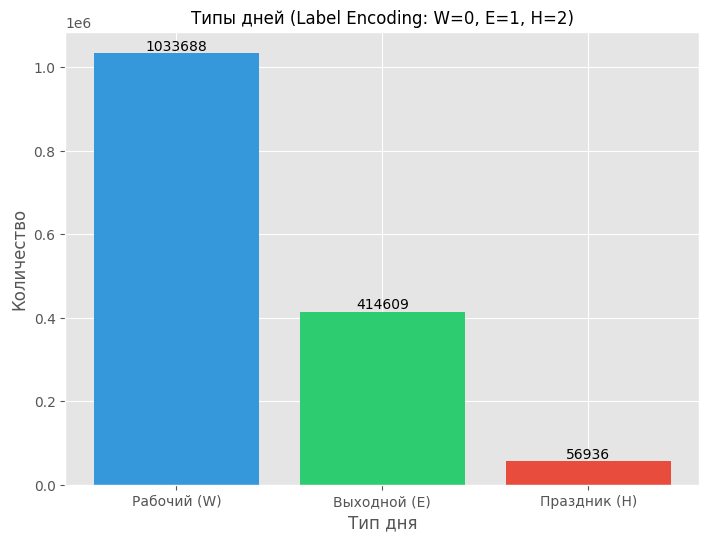

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('ggplot')
plt.figure(figsize=(18, 20))

# 1. Распределение типов дней (Label Encoded)
plt.subplot(3, 2, 1)
day_counts = data_encoded['researchDayType'].value_counts().sort_index()
bars = plt.bar(['Рабочий (W)', 'Выходной (E)', 'Праздник (H)'], day_counts,
               color=['#3498db', '#2ecc71', '#e74c3c'])
plt.title('Типы дней (Label Encoding: W=0, E=1, H=2)', fontsize=12)
plt.xlabel('Тип дня')
plt.ylabel('Количество')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

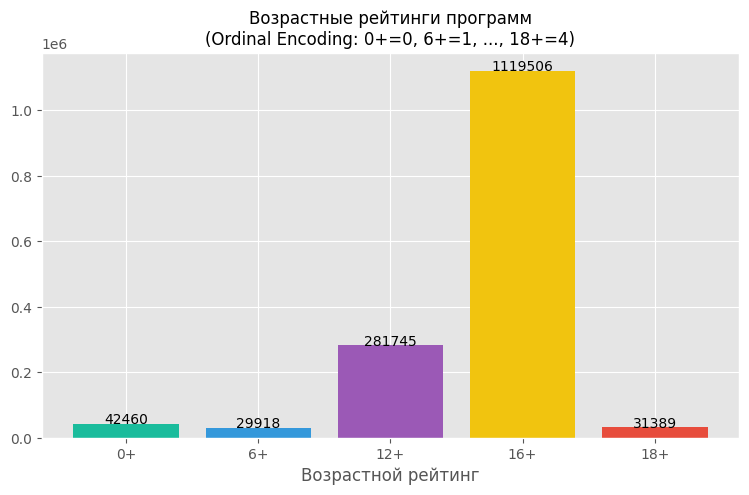

In [ ]:
# 2. Возрастные рейтинги (Ordinal Encoded)
plt.figure(figsize=(9, 5))
age_order = ['0+', '6+', '12+', '16+', '18+']
age_counts = data_encoded['programAgeRestrictionName'].value_counts().sort_index()
plt.bar(age_order, age_counts, color=['#1abc9c', '#3498db', '#9b59b6', '#f1c40f', '#e74c3c'])
plt.title('Возрастные рейтинги программ\n(Ordinal Encoding: 0+=0, 6+=1, ..., 18+=4)', fontsize=12)
plt.xlabel('Возрастной рейтинг')
for i, v in enumerate(age_counts):
    plt.text(i, v+50, str(v), ha='center')

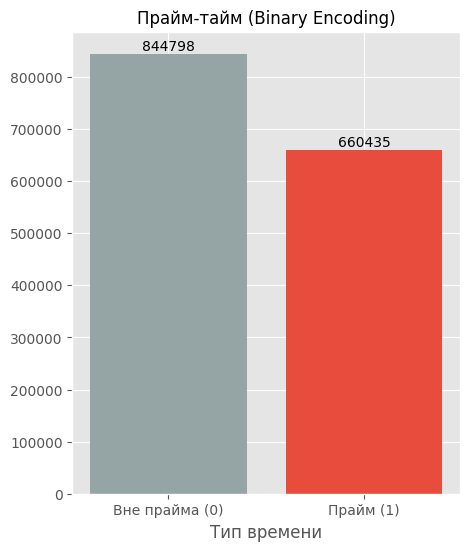

In [ ]:
# 3. Прайм-тайм (Binary Encoded)
plt.figure(figsize=(5, 6))
prime_counts = data_encoded['breaksPrimeTimeStatusName'].value_counts().sort_index()
bars = plt.bar(['Вне прайма (0)', 'Прайм (1)'], prime_counts,
               color=['#95a5a6', '#e74c3c'])
plt.title('Прайм-тайм (Binary Encoding)', fontsize=12)
plt.xlabel('Тип времени')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

Text(0.5, 0, 'Количество')

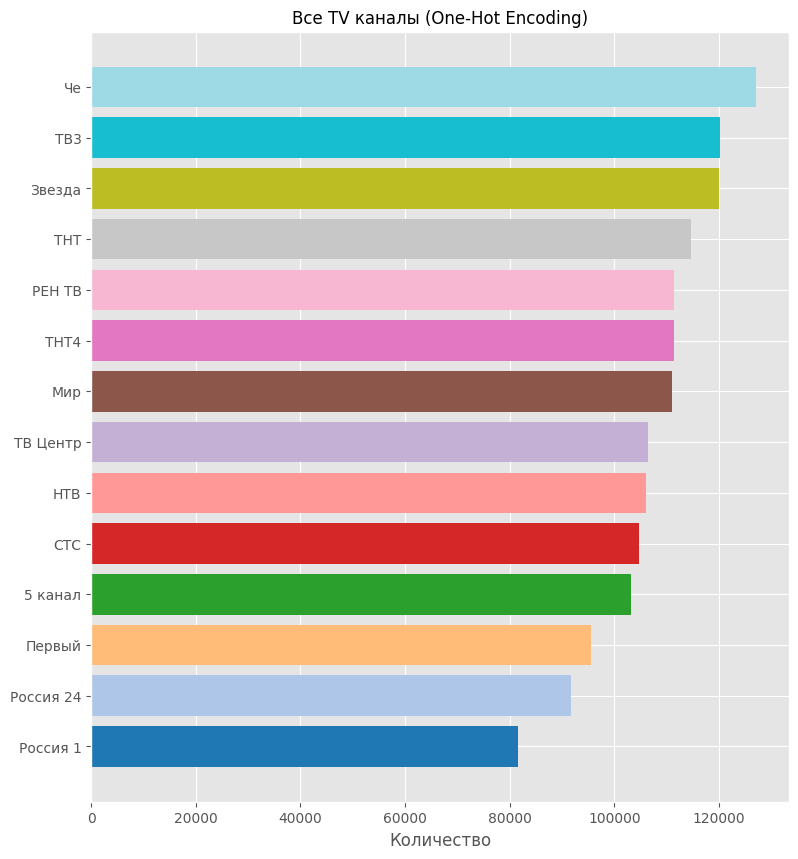

In [ ]:
# 4. Все TV каналы (One-Hot)
plt.figure(figsize=(9, 10))
tv_cols = [col for col in data_encoded.columns if 'tvCompanyName_' in col]
tv_counts = data_encoded[tv_cols].sum().sort_values()
plt.barh([x.replace('tvCompanyName_', '') for x in tv_counts.index], tv_counts,
         color=plt.cm.tab20(np.linspace(0, 1, len(tv_counts))))
plt.title('Все TV каналы (One-Hot Encoding)', fontsize=12)
plt.xlabel('Количество')

Text(0.5, 0, 'Количество')

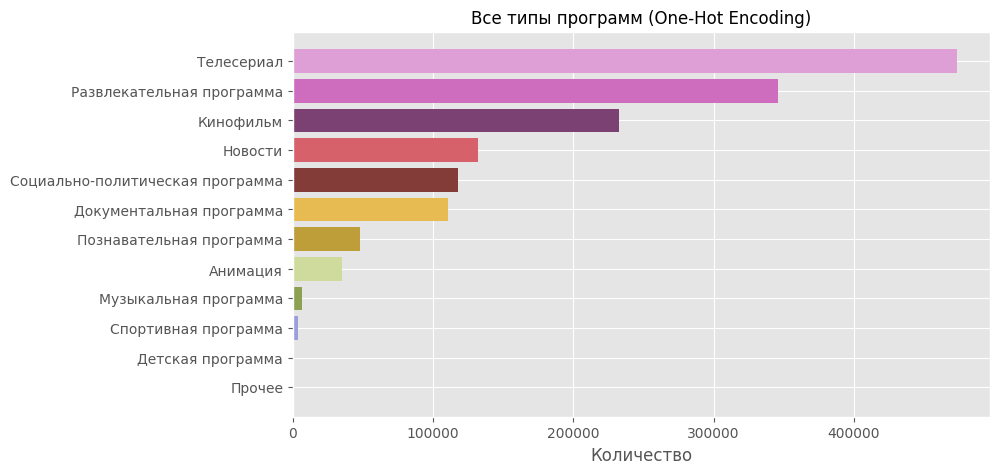

In [ ]:
# 5. Все типы программ (One-Hot)
plt.figure(figsize=(9, 5))
type_cols = [col for col in data_encoded.columns if 'programTypeName_' in col]
type_counts = data_encoded[type_cols].sum().sort_values()
plt.barh([x.replace('programTypeName_', '') for x in type_counts.index], type_counts,
         color=plt.cm.tab20b(np.linspace(0, 1, len(type_counts))))
plt.title('Все типы программ (One-Hot Encoding)', fontsize=12)
plt.xlabel('Количество')

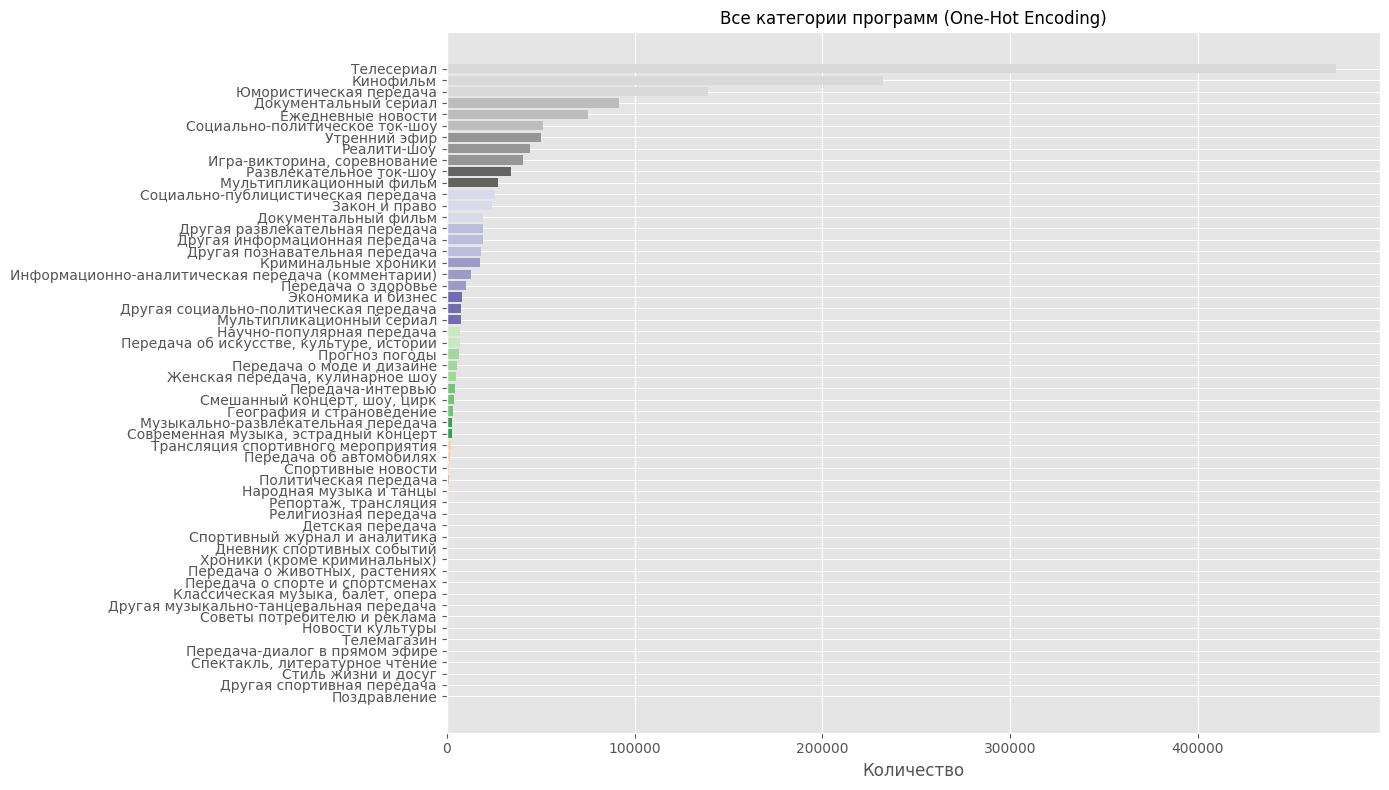

In [ ]:
# 6. Все категории программ (One-Hot)
plt.figure(figsize=(14, 8))
cat_cols = [col for col in data_encoded.columns if 'programCategoryName_' in col]
cat_counts = data_encoded[cat_cols].sum().sort_values()
plt.barh([x.replace('programCategoryName_', '') for x in cat_counts.index], cat_counts,
         color=plt.cm.tab20c(np.linspace(0, 1, len(cat_counts))))
plt.title('Все категории программ (One-Hot Encoding)', fontsize=12)
plt.xlabel('Количество')

plt.tight_layout()
plt.show()

# Создание новых признаков

In [ ]:
# День недели (0-6 соответственно)
data_encoded['day_of_week'] = data_encoded['researchDate'].dt.dayofweek

# Месяц (1-12 соответственно)
data_encoded['month'] = data_encoded['researchDate'].dt.month

# Сезон: 1-зима, 2-весна, 3-лето, 4-осень
def get_season(month):
  if month in [12, 1, 2]:
    return 1
  elif month in [3, 4, 5]:
    return 2
  elif month in [6, 7, 8]:
    return 3
  else:
    return 4
data_encoded['season'] = data_encoded['month'].apply(get_season)

Теперь сделаем-ка красивый вывод!

=== Первые 5 записей с новыми признаками ===


,researchDate,day_of_week,month,season
0,2020-01-01 00:00:00,Среда,Январь,Зима
1,2020-01-01 00:00:00,Среда,Январь,Зима
2,2020-01-01 00:00:00,Среда,Январь,Зима
3,2020-01-01 00:00:00,Среда,Январь,Зима
4,2020-01-01 00:00:00,Среда,Январь,Зима



=== Распределение по дням недели ===


,День,Количество,%
day_of_week,,,
Воскресенье,Понедельник,205443,13.600000
Вторник,Вторник,218457,14.500000
Понедельник,Среда,217118,14.400000
Пятница,Четверг,217035,14.400000
Среда,Пятница,218278,14.500000
Суббота,Суббота,211056,14.000000
Четверг,Воскресенье,217846,14.500000



=== Распределение по месяцам ===


,Месяц,Количество,%
month,,,
Август,Январь,127302,8.500000
Апрель,Февраль,118728,7.900000
Декабрь,Март,126073,8.400000
Июль,Апрель,125234,8.300000
Июнь,Май,119284,7.900000
Май,Июнь,123176,8.200000
Март,Июль,121970,8.100000
Ноябрь,Август,130796,8.700000
Октябрь,Сентябрь,128808,8.600000



=== Распределение по сезонам ===


,Сезон,Количество,%
season,,,
Весна,Зима,363874,24.200000
Зима,Весна,387176,25.700000
Лето,Лето,371820,24.700000
Осень,Осень,382363,25.400000


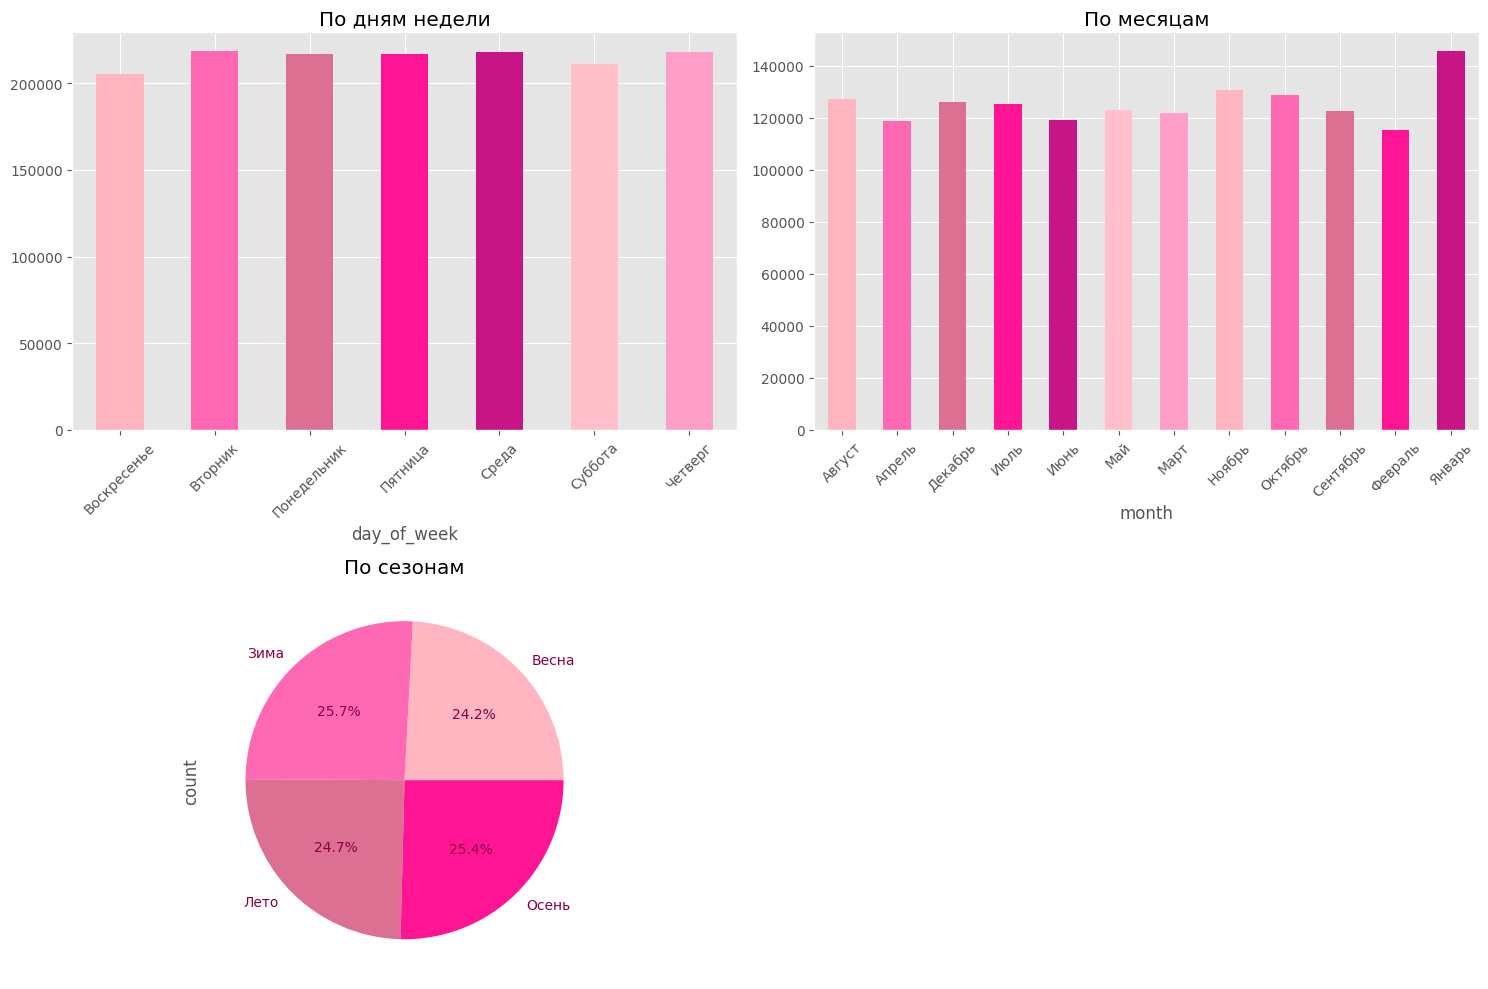

In [ ]:
# Словари для красивых названий
day_names = {0: 'Понедельник', 1: 'Вторник', 2: 'Среда',
             3: 'Четверг', 4: 'Пятница', 5: 'Суббота', 6: 'Воскресенье'}

month_names = {1: 'Январь', 2: 'Февраль', 3: 'Март', 4: 'Апрель',
               5: 'Май', 6: 'Июнь', 7: 'Июль', 8: 'Август',
               9: 'Сентябрь', 10: 'Октябрь', 11: 'Ноябрь', 12: 'Декабрь'}

season_names = {1: 'Зима', 2: 'Весна', 3: 'Лето', 4: 'Осень'}

# 1. Проверка первых записей
print("=== Первые 5 записей с новыми признаками ===")
display(data_encoded[['researchDate', 'day_of_week', 'month', 'season']].head().style
        .set_caption("Пример данных")
        .format({'day_of_week': lambda x: day_names[x],
                 'month': lambda x: month_names[x],
                 'season': lambda x: season_names[x]}))

# 2. Распределение по дням недели
day_counts = data_encoded['day_of_week'].value_counts().rename(index=day_names).sort_index()
day_percents = (day_counts/day_counts.sum()*100).round(1)

print("\n=== Распределение по дням недели ===")
day_df = pd.DataFrame({'День': day_names.values(),
                       'Количество': day_counts,
                       '%': day_percents})
display(day_df.style.bar(color='#ba5faf'))

# 3. Распределение по месяцам
month_counts = data_encoded['month'].value_counts().rename(index=month_names).sort_index()
month_percents = (month_counts/month_counts.sum()*100).round(1)

print("\n=== Распределение по месяцам ===")
month_df = pd.DataFrame({'Месяц': month_names.values(),
                         'Количество': month_counts,
                         '%': month_percents})
display(month_df.style.background_gradient(cmap='RdPu'))

# 4. Распределение по сезонам
season_counts = data_encoded['season'].value_counts().rename(index=season_names).sort_index()
season_percents = (season_counts/season_counts.sum()*100).round(1)

print("\n=== Распределение по сезонам ===")
season_df = pd.DataFrame({'Сезон': season_names.values(),
                          'Количество': season_counts,
                          '%': season_percents})
display(season_df.style.set_properties(**{'background-color': '#ffebf3',
                                         'color': '#8b0043'}))

# 5. Визуализация
plt.figure(figsize=(15, 10))

# Цветовая палитра
pink_palette = ['#ffb6c1', '#ff69b4', '#db7093', '#ff1493', '#c71585', '#ffc0cb', '#ff9ec6']

plt.subplot(2, 2, 1)
data_encoded['day_of_week'].value_counts().rename(index=day_names).sort_index().plot(
    kind='bar', color=pink_palette, title='По дням недели')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
data_encoded['month'].value_counts().rename(index=month_names).sort_index().plot(
    kind='bar', color=pink_palette, title='По месяцам')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
data_encoded['season'].value_counts().rename(index=season_names).sort_index().plot(
    kind='pie', autopct='%1.1f%%', colors=pink_palette[:4],
    title='По сезонам', textprops={'color': '#8b0043'})

plt.tight_layout()
plt.show()

# Создание лагов и скользящих средних

In [ ]:
# Создание лагов (сдвиги назад)
data['lag_1'] = data['SalesRtgPer'].shift(1)
data['lag_5'] = data['SalesRtgPer'].shift(5)

# Скользящее среднее
data['rolling_mean_5'] = data['SalesRtgPer'].rolling(window=5).mean()
data['rolling_mean_10'] = data['SalesRtgPer'].rolling(window=10).mean()

Для отображения используем корреляционную таблицу

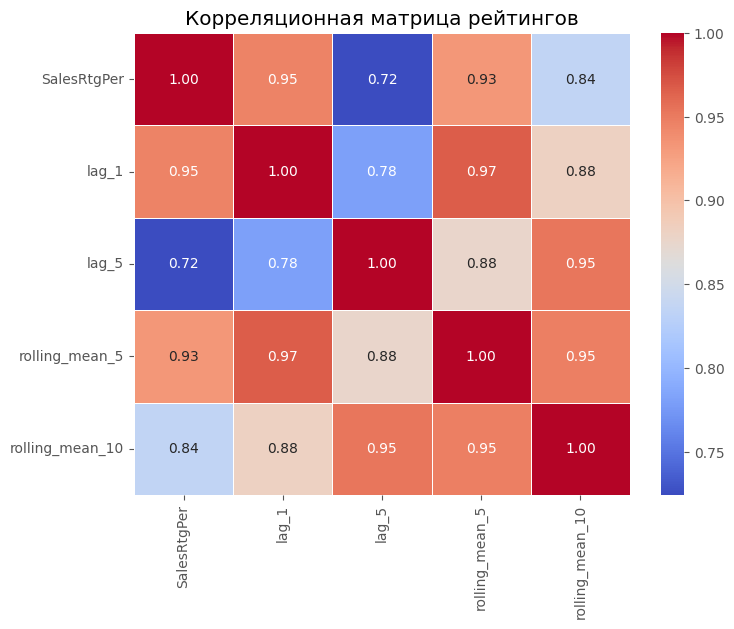

In [ ]:
# Вычисление корреляции
corr_matrix = data[['SalesRtgPer', 'lag_1', 'lag_5', 'rolling_mean_5', 'rolling_mean_10']].corr()

# Построение тепловой карты
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Корреляционная матрица рейтингов')
plt.show()